In [5]:
pip install pymupdf

In [6]:
import fitz  # PyMuPDF
import re
import requests

def download_pdf(url, save_path):
    response = requests.get(url)
    with open(save_path, 'wb') as f:
        f.write(response.content)

def search_for_count(file_path, keyword):
    doc = fitz.open(file_path)
    results = []

    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text("text")

        # Adjusted regex pattern to capture count directly after the keyword
        pattern = rf"{keyword}\s+(\d{{1,3}}(?:,\d{{3}})*)"
        matches = re.finditer(pattern, text, re.IGNORECASE)

        for match in matches:
            count = match.group(1)  # Extract the number
            results.append({"page": page_num + 1, "count": count, "context": match.group(0).strip()})

    doc.close()
    return results

# Usage
url = "https://www.alabamapublichealth.gov/healthstats/assets/ataglance2022.pdf"
pdf_path = "downloaded_report.pdf"
keyword = "Alzheimer’s Disease"  # Specify the exact phrase

# Download and search
download_pdf(url, pdf_path)
search_results = search_for_count(pdf_path, keyword)

# Check results
if search_results:
    for result in search_results:
        print(f"Found on page {result['page']}: {result['count']} (Context: {result['context']})")
else:
    print("No Alzheimer's Disease count found.")


Found on page 2: 2,651 (Context: Alzheimer’s Disease
2,651)


In [ ]:
# Step 1: Import the necessary libraries
import pandas as pd
from google.colab import files

# Step 2: Upload the .xlsx file
uploaded = files.upload()

# Step 3: Read the Excel file (replace 'your_file.xlsx' with the actual file name)
df = pd.read_excel(next(iter(uploaded.keys())))

# Step 4: Display the first few rows of the dataframe to check the data
print(df.head())


Saving Capstone Data 11.xlsx to Capstone Data 11.xlsx
    States Preempted  Years Years Ordered  Population  Alzheimer  \
0  Alabama         X   2014        Year 1     4849377       1379   
1  Alabama         X   2015        Year 2     4858979       1512   
2  Alabama         X   2016        Year 3     4863300       1646   
3  Alabama         X   2017        Year 4     4850771       1788   
4  Alabama         X   2018        Year 5     4887871       2025   

   Cardiovascular Disease  Respiratory Diseases  Cancer  Diabetes  ...  \
0                   12442                  3050   10286      1281  ...   
1                   12589                  3279   10354      1255  ...   
2                   12719                  3326   10419      1183  ...   
3                   12799                  3484   10410      1173  ...   
4                   13011                  3596   10632      1176  ...   

   Care Avoided due to Cost perc  Median Income  Income inequality  \
0                     

In [ ]:
# Replace 'X' with 1 and None (NULL) with 0 in the "Preempted" column
df['Preempted'] = df['Preempted'].apply(lambda x: 1 if x == "X" else 0)

import pandas as pd

# Define the federal minimum wage
federal_min_wage = 7.25

# Calculate the percentage difference and create the new column
df['State vs Federal Wage perc diff'] = ((df['Current State Min Wage'] - federal_min_wage) / federal_min_wage) * 100

# Display the transformed DataFrame
print(df)

      States  Preempted  Years Years Ordered  Population  Alzheimer  \
0    Alabama          1   2014        Year 1     4849377       1379   
1    Alabama          1   2015        Year 2     4858979       1512   
2    Alabama          1   2016        Year 3     4863300       1646   
3    Alabama          1   2017        Year 4     4850771       1788   
4    Alabama          1   2018        Year 5     4887871       2025   
..       ...        ...    ...           ...         ...        ...   
245  Wyoming          0   2006        Year 1      552667        112   
246  Wyoming          0   2007        Year 2      534876        110   
247  Wyoming          0   2008        Year 3      546043        125   
248  Wyoming          0   2009        Year 4      559851        136   
249  Wyoming          0   2010        Year 5      564531        146   

     Cardiovascular Disease  Respiratory Diseases  Cancer  Diabetes  ...  \
0                     12442                  3050   10286      1281  ..

In [ ]:
df2=df.copy()
# Create a list of numbers from 1 to 50, each repeated 5 times
state_numbers = [i+1 for i in range(50)] * 5

# Ensure the list matches the number of rows in the DataFrame
if len(state_numbers) == len(df2):
    df2['States'] = state_numbers
else:
    print(f"Mismatch: The number of rows in state_numbers ({len(state_numbers)}) does not match the number of rows in the DataFrame ({len(df2)}).")

# Output the updated DataFrame
print(df2)



     States  Preempted  Years Years Ordered  Population  Alzheimer  \
0         1          1   2014        Year 1     4849377       1379   
1         2          1   2015        Year 2     4858979       1512   
2         3          1   2016        Year 3     4863300       1646   
3         4          1   2017        Year 4     4850771       1788   
4         5          1   2018        Year 5     4887871       2025   
..      ...        ...    ...           ...         ...        ...   
245      46          0   2006        Year 1      552667        112   
246      47          0   2007        Year 2      534876        110   
247      48          0   2008        Year 3      546043        125   
248      49          0   2009        Year 4      559851        136   
249      50          0   2010        Year 5      564531        146   

     Cardiovascular Disease  Respiratory Diseases  Cancer  Diabetes  ...  \
0                     12442                  3050   10286      1281  ...   
1      

In [ ]:
df

,States,Preempted,Years,Years Ordered,Population,Alzheimer,Cardiovascular Disease,Respiratory Diseases,Cancer,Diabetes,...,Median Income,Income inequality,Housing Insecurity,Cost of Living Index,Child Mortality,Food Insecurity Perc,Current State Min Wage,Compared to Federal Wage,Annual Avg Temp,State vs Federal Wage perc diff
0,Alabama,1,2014,Year 1,4849377,1379,12442,3050,10286,1281,...,42278,0.4597,4.0,13.2,129,16.3,7.25,E,63.6,0.0
1,Alabama,1,2015,Year 2,4858979,1512,12589,3279,10354,1255,...,44509,0.4616,4.0,13.5,112,18.0,7.25,E,64.7,0.0
2,Alabama,1,2016,Year 3,4863300,1646,12719,3326,10419,1183,...,47221,0.4791,4.0,14.1,96,14.4,7.25,E,65.8,0.0
3,Alabama,1,2017,Year 4,4850771,1788,12799,3484,10410,1173,...,50865,0.4772,4.0,16.3,116,16.0,7.25,E,64.9,0.0
4,Alabama,1,2018,Year 5,4887871,2025,13011,3596,10632,1176,...,49881,0.4756,3.8,15.0,106,15.0,7.25,E,64.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Wyoming,0,2006,Year 1,552667,112,994,345,927,126,...,48505,0.4510,1.4,12.6,17,7.8,7.25,E,42.1,0.0
246,Wyoming,0,2007,Year 2,534876,110,957,295,940,139,...,49688,0.4520,1.4,13.0,12,9.0,7.25,E,43.0,0.0
247,Wyoming,0,2008,Year 3,546043,125,937,311,874,130,...,50832,0.4530,1.4,13.3,17,8.0,7.25,E,41.4,0.0
248,Wyoming,0,2009,Year 4,559851,136,964,310,936,105,...,51672,0.4520,1.6,13.7,15,10.0,7.25,E,41.6,0.0


In [ ]:
# List of columns for which we want to calculate mortality rate per 100,000 people
disease_columns = [
    'Alzheimer', 'Cardiovascular Disease', 'Respiratory Diseases', 'Cancer',
    'Diabetes', 'Kidney Disease', 'Suicide', 'HIV', 'Firearm Mortality',
    'Violent Crime Mortality', 'Drug Deaths', 'Obesity', 'Child Mortality'
]

# Calculate mortality rate per 100,000 for each disease/mortality column
for column in disease_columns:
    df[f'{column} Rate per 100k'] = (df[column] / df['Population']) * 100000

# Display the updated dataframe with new mortality rate columns
print(df[[col for col in df.columns if 'Rate per 100k' in col]].head())

   Alzheimer Rate per 100k  Cardiovascular Disease Rate per 100k  \
0                28.436642                            256.569040   
1                31.117648                            259.087351   
2                33.845331                            261.530237   
3                36.860120                            263.854962   
4                41.429080                            266.189513   

   Respiratory Diseases Rate per 100k  Cancer Rate per 100k  \
0                           62.894677            212.109720   
1                           67.483313            213.090034   
2                           68.389776            214.237246   
3                           71.823634            214.605060   
4                           73.569863            217.518016   

   Diabetes Rate per 100k  Kidney Disease Rate per 100k  \
0               26.415764                     20.848039   
1               25.828471                     21.403673   
2               24.325047          

In [ ]:
df


,States,Preempted,Years,Years Ordered,Population,Alzheimer,Cardiovascular Disease,Respiratory Diseases,Cancer,Diabetes,...,Cancer Rate per 100k,Diabetes Rate per 100k,Kidney Disease Rate per 100k,Suicide Rate per 100k,HIV Rate per 100k,Firearm Mortality Rate per 100k,Violent Crime Mortality Rate per 100k,Drug Deaths Rate per 100k,Obesity Rate per 100k,Child Mortality Rate per 100k
0,Alabama,1,2014,Year 1,4849377,1379,12442,3050,10286,1281,...,212.109720,26.415764,20.848039,14.744162,2.618893,16.806283,7.712331,15.177207,9969.486802,2.660136
1,Alabama,1,2015,Year 2,4858979,1512,12589,3279,10354,1255,...,213.090034,25.828471,21.403673,15.435341,2.593137,19.716076,9.734555,15.558824,10434.023279,2.305011
2,Alabama,1,2016,Year 3,4863300,1646,12719,3326,10419,1183,...,214.237246,24.325047,20.808916,16.202990,2.179590,21.508030,11.185820,15.935682,11365.800999,1.973968
3,Alabama,1,2017,Year 4,4850771,1788,12799,3484,10410,1173,...,214.605060,24.181723,20.202974,17.234374,1.958452,23.171574,12.410398,17.234374,11041.131400,2.391372
4,Alabama,1,2018,Year 5,4887871,2025,13011,3596,10632,1176,...,217.518016,24.059555,21.215781,16.837597,1.902669,21.768169,11.620601,17.103561,11255.391151,2.168633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Wyoming,0,2006,Year 1,552667,112,994,345,927,126,...,167.732106,22.798539,10.494565,20.989131,1.628467,14.475263,0.000000,15.379967,4575.449593,3.075993
246,Wyoming,0,2007,Year 2,534876,110,957,295,940,139,...,175.741667,25.987332,12.713227,18.882881,2.056551,14.208901,3.178307,17.948085,5169.983323,2.243511
247,Wyoming,0,2008,Year 3,546043,125,937,311,874,130,...,160.060655,23.807649,10.255603,22.708834,1.831358,17.031626,3.296444,13.368911,5350.128103,3.113308
248,Wyoming,0,2009,Year 4,559851,136,964,310,936,105,...,167.187341,18.754990,13.575041,19.826704,1.071714,17.147420,3.036522,10.717137,5030.088363,2.679284


In [ ]:
# List of columns to drop
columns_to_drop = [
    'Alzheimer', 'Cardiovascular Disease', 'Respiratory Diseases', 'Cancer',
    'Diabetes', 'Kidney Disease', 'Suicide', 'HIV', 'Firearm Mortality',
    'Violent Crime Mortality', 'Drug Deaths', 'Obesity'
]

# Drop the columns
df = df.drop(columns=columns_to_drop)

# Display the updated DataFrame
print(df.head())

    States  Preempted  Years Years Ordered  Population  Infant Mortality Rate  \
0  Alabama          1   2014        Year 1     4849377                   8.92   
1  Alabama          1   2015        Year 2     4858979                   8.53   
2  Alabama          1   2016        Year 3     4863300                   9.22   
3  Alabama          1   2017        Year 4     4850771                   7.50   
4  Alabama          1   2018        Year 5     4887871                   7.14   

   White perc  Black perc  Care Avoided due to Cost perc  Median Income  ...  \
0       66.21        26.2                           17.4          42278  ...   
1       66.21        26.2                           16.5          44509  ...   
2       66.21        26.2                           16.4          47221  ...   
3       66.21        26.2                           16.5          50865  ...   
4       66.21        26.2                           16.2          49881  ...   

   Cancer Rate per 100k  Diabete

In [ ]:
!pip install seaborn matplotlib scipy

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

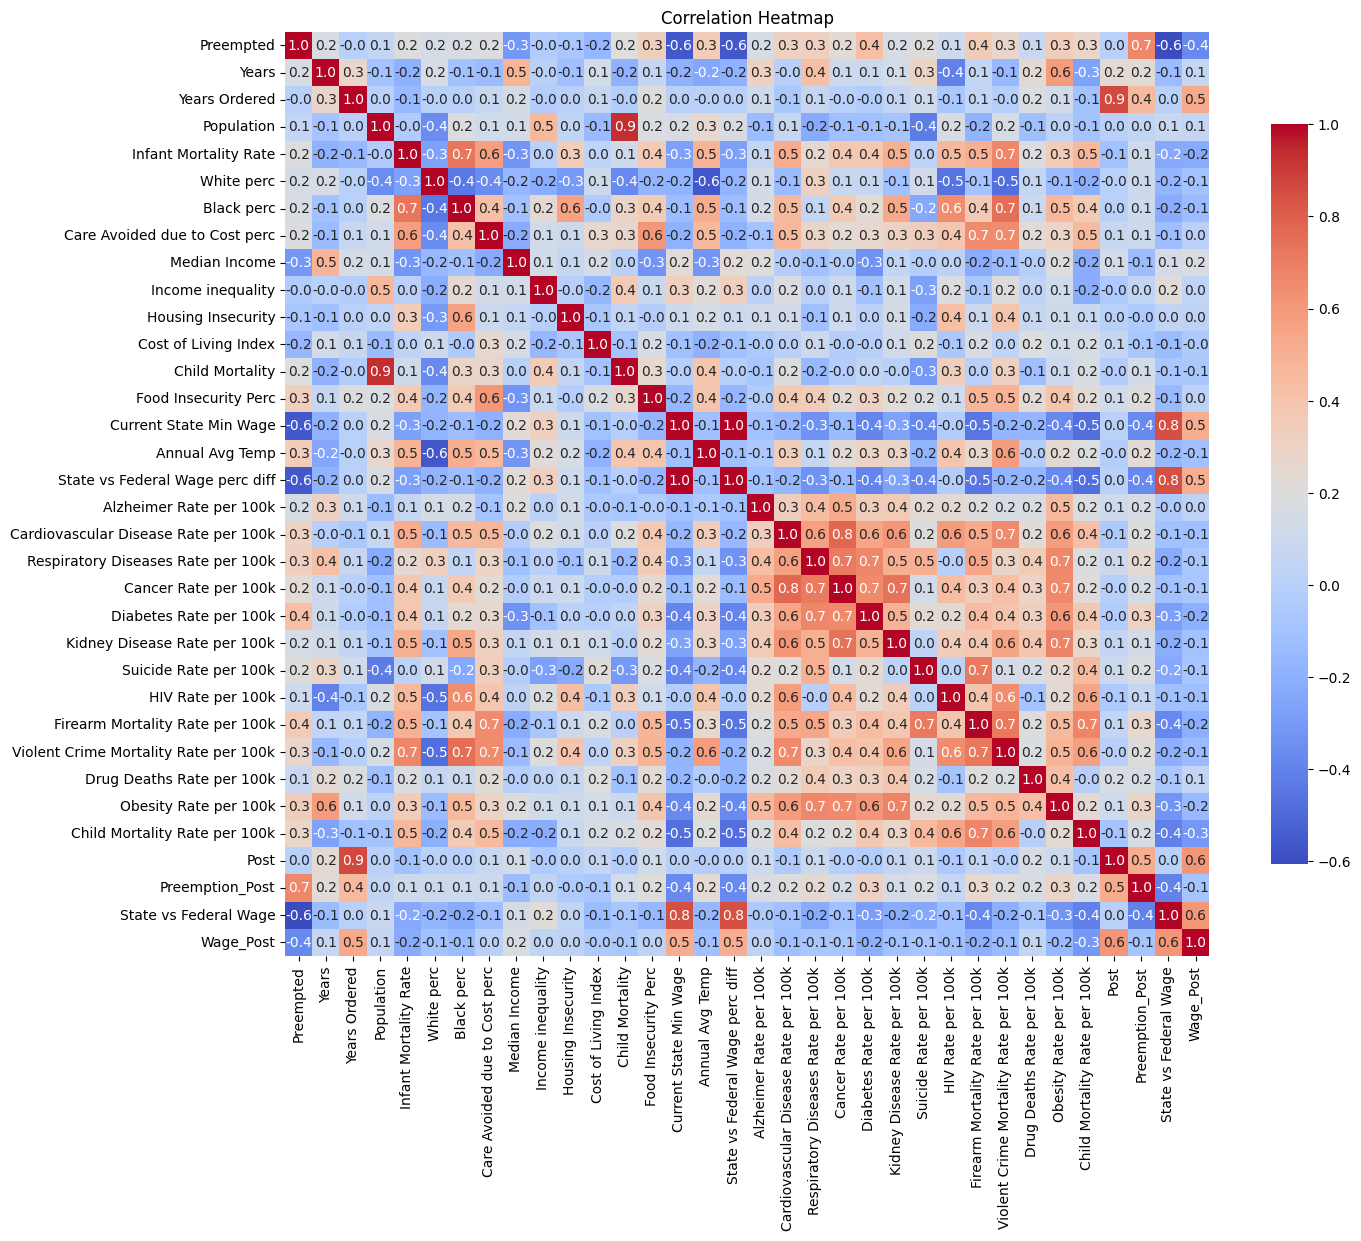

In [ ]:
# Select only numeric columns for correlation calculation
df_numeric = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Plot the correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", square=True, cbar_kws={'shrink': .8})
plt.title("Correlation Heatmap")
plt.show()

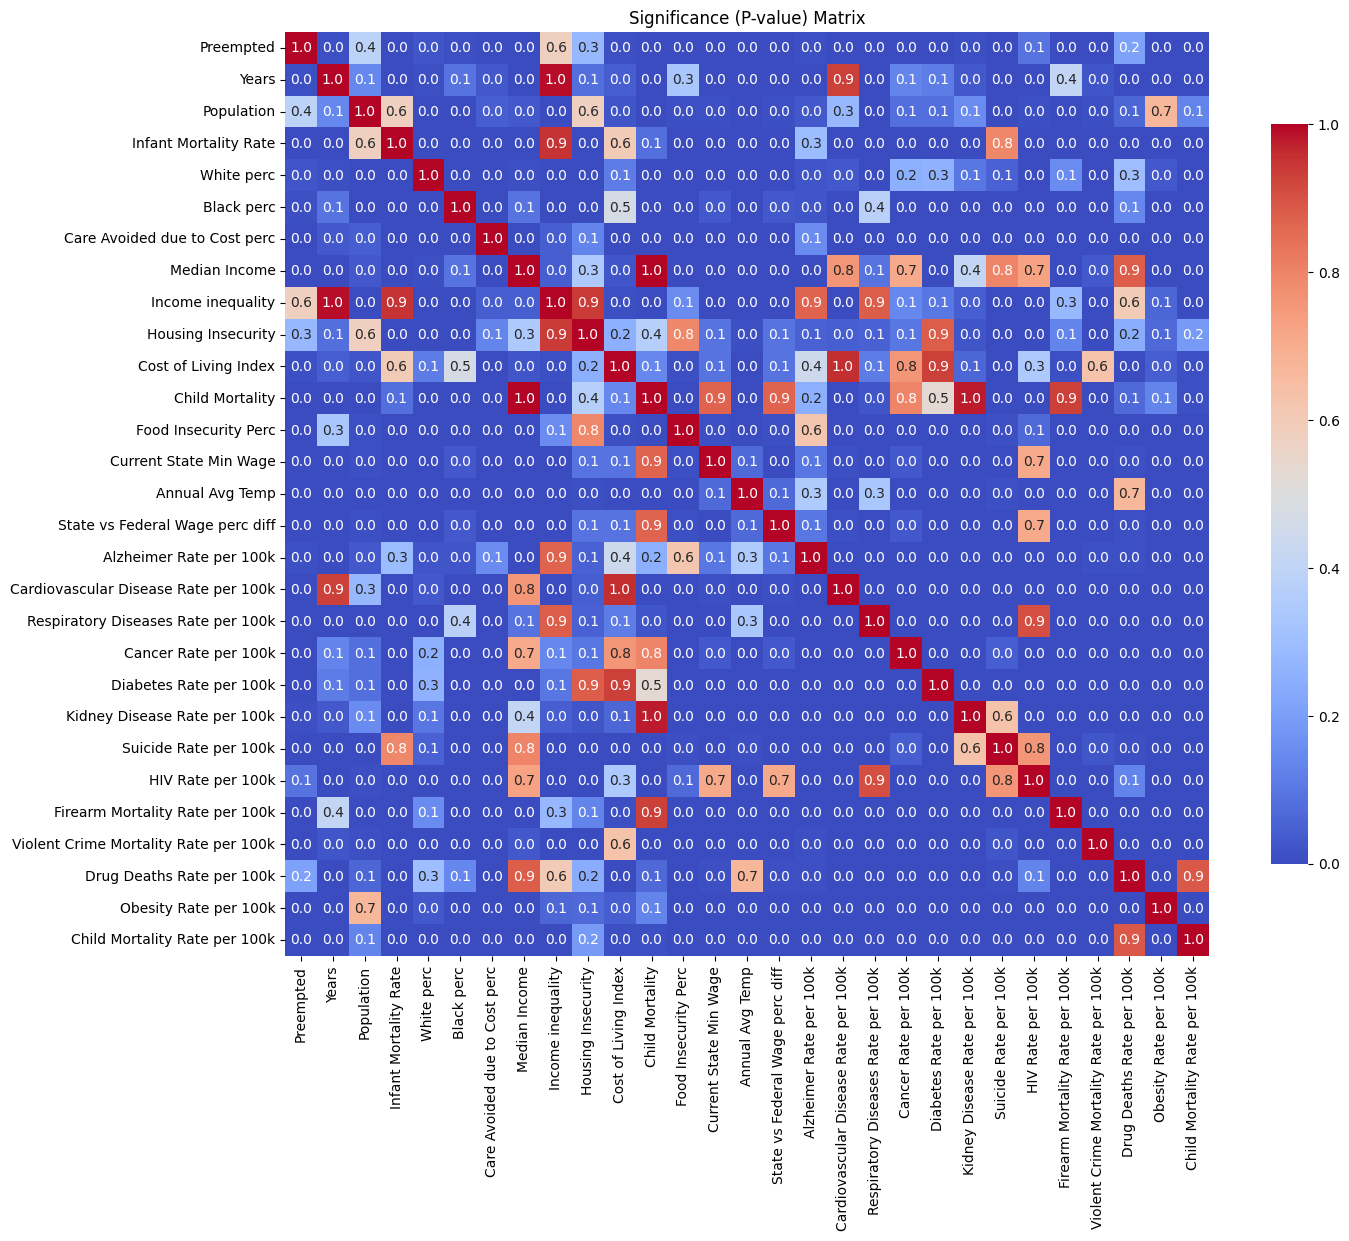

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Function to calculate p-values for each pair of features in the numeric dataframe
def calculate_p_values(df, threshold=1e-5, decimals=2):
    df_numeric = df.select_dtypes(include=[np.number])  # Ensure only numeric columns
    p_matrix = pd.DataFrame(np.ones((df_numeric.shape[1], df_numeric.shape[1])), columns=df_numeric.columns, index=df_numeric.columns)

    for col in df_numeric.columns:
        for row in df_numeric.columns:
            if col != row:
                _, p = pearsonr(df_numeric[col], df_numeric[row])
                # Round p-value to desired number of decimals
                p = round(p, decimals)
                # Set a threshold for very small p-values
                if p < threshold:
                    p = 0.0
                p_matrix.loc[row, col] = p

    return p_matrix

# Calculate the p-value matrix
p_values = calculate_p_values(df_numeric)

# Plot the significance matrix
plt.figure(figsize=(16, 12))
sns.heatmap(p_values, annot=True, fmt=".1f", cmap="coolwarm", square=True, cbar_kws={'shrink': .8})
plt.title("Significance (P-value) Matrix")
plt.show()


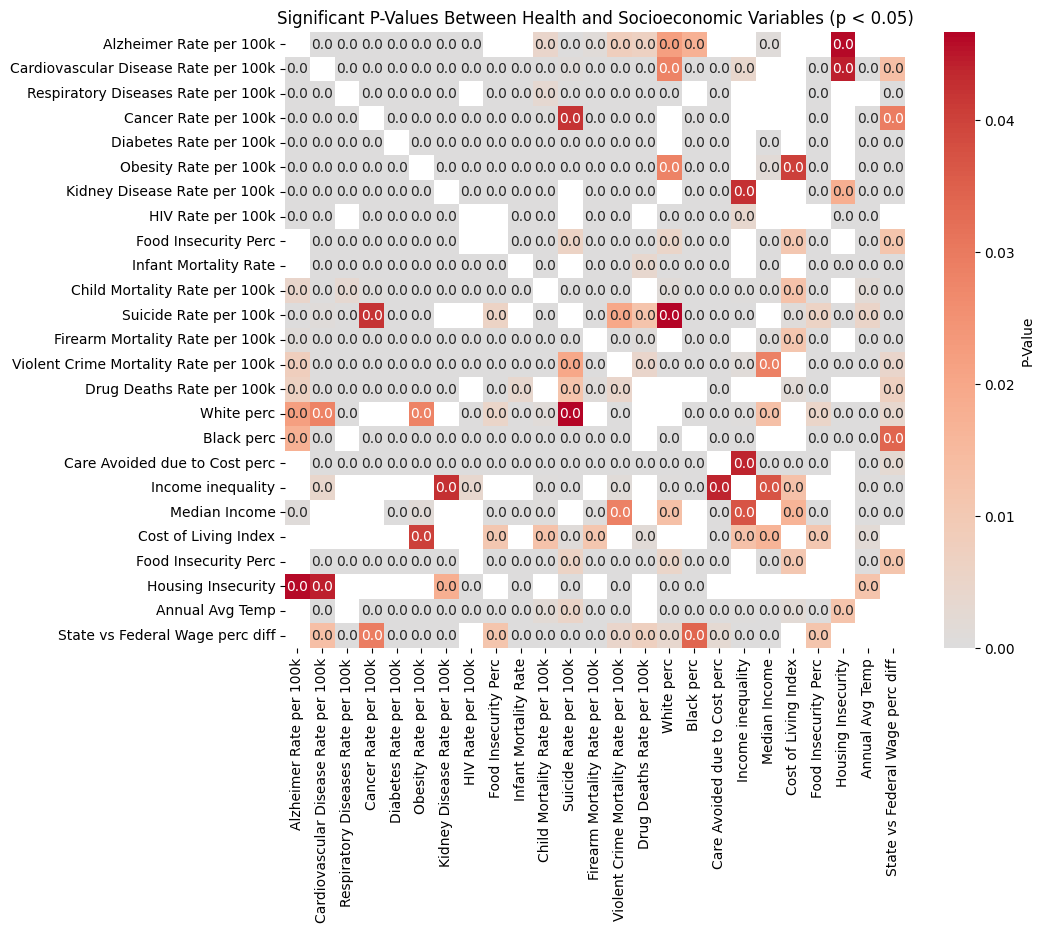

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Sample selected variables
selected_vars = ['Alzheimer Rate per 100k','Cardiovascular Disease Rate per 100k','Respiratory Diseases Rate per 100k','Cancer Rate per 100k','Diabetes Rate per 100k','Obesity Rate per 100k','Kidney Disease Rate per 100k','HIV Rate per 100k','Food Insecurity Perc', 'Infant Mortality Rate', 'Child Mortality Rate per 100k','Suicide Rate per 100k','Firearm Mortality Rate per 100k','Violent Crime Mortality Rate per 100k','Drug Deaths Rate per 100k','White perc','Black perc','Care Avoided due to Cost perc','Income inequality','Median Income','Cost of Living Index','Food Insecurity Perc', 'Housing Insecurity','Annual Avg Temp','State vs Federal Wage perc diff']

# Initialize correlation and p-value matrices
correlation_matrix = df[selected_vars].corr()
p_values = pd.DataFrame(np.ones((len(selected_vars), len(selected_vars))),
                        columns=selected_vars, index=selected_vars)

# Calculate p-values
for i in range(len(selected_vars)):
    for j in range(i + 1, len(selected_vars)):
        corr, p_val = stats.pearsonr(df[selected_vars[i]], df[selected_vars[j]])
        p_values.iloc[i, j] = p_val
        p_values.iloc[j, i] = p_val

# Replace non-significant p-values with NaN
significant_p_values = p_values.where(p_values < 0.05)

plt.figure(figsize=(10, 8))

# Draw heatmap of p-values for significant correlations only
sns.heatmap(significant_p_values, annot=True, fmt=".1f", cmap='coolwarm', center=0,
            cbar_kws={"label": "P-Value"})
plt.title('Significant P-Values Between Health and Socioeconomic Variables (p < 0.05)')
plt.show()


In [ ]:
df.head(10)


,States,Preempted,Years,Years Ordered,Population,Infant Mortality Rate,White perc,Black perc,Care Avoided due to Cost perc,Median Income,...,Cancer Rate per 100k,Diabetes Rate per 100k,Kidney Disease Rate per 100k,Suicide Rate per 100k,HIV Rate per 100k,Firearm Mortality Rate per 100k,Violent Crime Mortality Rate per 100k,Drug Deaths Rate per 100k,Obesity Rate per 100k,Child Mortality Rate per 100k
0,Alabama,1,2014,Year 1,4849377,8.92,66.21,26.2,17.4,42278,...,212.109720,26.415764,20.848039,14.744162,2.618893,16.806283,7.712331,15.177207,9969.486802,2.660136
1,Alabama,1,2015,Year 2,4858979,8.53,66.21,26.2,16.5,44509,...,213.090034,25.828471,21.403673,15.435341,2.593137,19.716076,9.734555,15.558824,10434.023279,2.305011
2,Alabama,1,2016,Year 3,4863300,9.22,66.21,26.2,16.4,47221,...,214.237246,24.325047,20.808916,16.202990,2.179590,21.508030,11.185820,15.935682,11365.800999,1.973968
3,Alabama,1,2017,Year 4,4850771,7.50,66.21,26.2,16.5,50865,...,214.605060,24.181723,20.202974,17.234374,1.958452,23.171574,12.410398,17.234374,11041.131400,2.391372
4,Alabama,1,2018,Year 5,4887871,7.14,66.21,26.2,16.2,49881,...,217.518016,24.059555,21.215781,16.837597,1.902669,21.768169,11.620601,17.103561,11255.391151,2.168633
5,Alaska,0,2006,Year 1,670520,7.44,64.10,3.4,15.6,56418,...,117.819006,16.256040,6.562071,20.133628,4.474139,16.554316,6.412933,11.334487,4101.592794,5.368967
6,Alaska,0,2007,Year 2,670053,6.76,64.10,3.4,17.3,62993,...,125.213976,15.670402,5.969677,22.237047,5.820435,17.909031,7.462096,13.133289,4394.876226,4.178774
7,Alaska,0,2008,Year 3,679720,6.20,64.10,3.4,18.4,63989,...,127.552522,13.682104,7.355970,24.863179,4.560701,20.890955,4.266463,14.417701,4796.828106,3.236627
8,Alaska,0,2009,Year 4,692314,6.95,64.10,3.4,19.5,61604,...,129.276600,12.133223,6.788827,20.655367,4.477737,15.022085,3.755521,15.888744,4276.527703,2.455533
9,Alaska,0,2010,Year 5,710231,3.97,64.10,3.4,17.4,57848,...,124.466547,12.108736,7.884759,23.091079,4.505576,20.275094,6.195167,17.599908,3789.752911,3.097584


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

preempted = df[df['Preempted'] == 1]  # Replace 'Preempted' with the appropriate column name
non_preempted = df[df['Preempted'] == 0]

# Health outcomes (Hypothesis 1)
health_outcomes = ['Alzheimer Rate per 100k','Cardiovascular Disease Rate per 100k','Respiratory Diseases Rate per 100k','Cancer Rate per 100k','Diabetes Rate per 100k','Obesity Rate per 100k','Kidney Disease Rate per 100k','HIV Rate per 100k','Food Insecurity Perc', 'Infant Mortality Rate', 'Child Mortality Rate per 100k']
for outcome in health_outcomes:
    t_stat, p_val = ttest_ind(preempted[outcome], non_preempted[outcome], equal_var=False)
    print(f"Health Outcome: {outcome}")
    print(f"  T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")
    print("  Significant difference" if p_val < 0.05 else "  No significant difference")

# Socio-economic inequalities (Hypothesis 2)
socio_inequalities = ['Suicide Rate per 100k','Firearm Mortality Rate per 100k','Violent Crime Mortality Rate per 100k','Drug Deaths Rate per 100k','White perc','Black perc','Care Avoided due to Cost perc','Income inequality','Median Income','Cost of Living Index','Food Insecurity Perc', 'Housing Insecurity','Annual Avg Temp','State vs Federal Wage perc diff']
for inequality in socio_inequalities:
    t_stat, p_val = ttest_ind(preempted[inequality], non_preempted[inequality], equal_var=False)
    print(f"Socio-economic Inequality: {inequality}")
    print(f"  T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")
    print("  Significant difference" if p_val < 0.05 else "  No significant difference")


Health Outcome: Alzheimer Rate per 100k
  T-statistic: 2.54, P-value: 0.0118
  Significant difference
Health Outcome: Cardiovascular Disease Rate per 100k
  T-statistic: 5.06, P-value: 0.0000
  Significant difference
Health Outcome: Respiratory Diseases Rate per 100k
  T-statistic: 5.40, P-value: 0.0000
  Significant difference
Health Outcome: Cancer Rate per 100k
  T-statistic: 3.68, P-value: 0.0003
  Significant difference
Health Outcome: Diabetes Rate per 100k
  T-statistic: 7.50, P-value: 0.0000
  Significant difference
Health Outcome: Obesity Rate per 100k
  T-statistic: 5.51, P-value: 0.0000
  Significant difference
Health Outcome: Kidney Disease Rate per 100k
  T-statistic: 2.51, P-value: 0.0129
  Significant difference
Health Outcome: HIV Rate per 100k
  T-statistic: 1.64, P-value: 0.1028
  No significant difference
Health Outcome: Food Insecurity Perc
  T-statistic: 5.50, P-value: 0.0000
  Significant difference
Health Outcome: Infant Mortality Rate
  T-statistic: 3.07, P-valu

In [ ]:
import pandas as pd

# Example data: Replace this with your actual results
results = {
    "Variable": [
        "Alzheimer Rate per 100k", "Cardiovascular Disease Rate per 100k", "Respiratory Diseases Rate per 100k",
        "Cancer Rate per 100k", "Diabetes Rate per 100k", "Obesity Rate per 100k", "Kidney Disease Rate per 100k",
        "HIV Rate per 100k", "Food Insecurity Perc", "Infant Mortality Rate", "Child Mortality Rate per 100k",
        "Suicide Rate per 100k", "Firearm Mortality Rate per 100k", "Violent Crime Mortality Rate per 100k",
        "Drug Deaths Rate per 100k", "White perc", "Black perc", "Care Avoided due to Cost perc",
        "Income inequality", "Median Income", "Cost of Living Index", "Housing Insecurity",
        "Annual Avg Temp","State vs Federal Wage perc diff"
    ],
    "T-statistic": [2.54, 5.06, 5.40, 3.68, 7.50, 5.51, 2.51, 1.64, 5.50, 3.07, 4.55, 3.39, 6.02, 4.47, 1.25,
                    2.44, 2.56, 2.93, -0.56, -5.17, -2.61, -1.11, 5.72, -10.71],
    "P-value": [0.0118, 0.0000, 0.0000, 0.0003, 0.0000, 0.0000, 0.0129, 0.1028, 0.0000, 0.0024, 0.0000, 0.0008,
                0.0000, 0.0000, 0.2131, 0.0154, 0.0111, 0.0037, 0.5775, 0.0000, 0.0096, 0.2692, 0.0000, 0.0000]
}

# Convert to a DataFrame
df_Pvalues = pd.DataFrame(results)

# Filter for significant variables (P-value < 0.05)
significant_results = df_Pvalues[df_Pvalues["P-value"] < 0.05]

# Display significant results
print(significant_results)

                                 Variable  T-statistic  P-value
0                 Alzheimer Rate per 100k         2.54   0.0118
1    Cardiovascular Disease Rate per 100k         5.06   0.0000
2      Respiratory Diseases Rate per 100k         5.40   0.0000
3                    Cancer Rate per 100k         3.68   0.0003
4                  Diabetes Rate per 100k         7.50   0.0000
5                   Obesity Rate per 100k         5.51   0.0000
6            Kidney Disease Rate per 100k         2.51   0.0129
8                    Food Insecurity Perc         5.50   0.0000
9                   Infant Mortality Rate         3.07   0.0024
10          Child Mortality Rate per 100k         4.55   0.0000
11                  Suicide Rate per 100k         3.39   0.0008
12        Firearm Mortality Rate per 100k         6.02   0.0000
13  Violent Crime Mortality Rate per 100k         4.47   0.0000
15                             White perc         2.44   0.0154
16                             Black per

In [ ]:
# Ensure that the 'Years Ordered' repeats Year 1 to Year 5 for every state
unique_states = df['States'].unique()
updated_years_ordered = [1, 2, 3, 4, 5] * len(unique_states)

df['Years Ordered'] = updated_years_ordered

df.head(10)

,States,Preempted,Years,Years Ordered,Population,Infant Mortality Rate,White perc,Black perc,Care Avoided due to Cost perc,Median Income,...,Cancer Rate per 100k,Diabetes Rate per 100k,Kidney Disease Rate per 100k,Suicide Rate per 100k,HIV Rate per 100k,Firearm Mortality Rate per 100k,Violent Crime Mortality Rate per 100k,Drug Deaths Rate per 100k,Obesity Rate per 100k,Child Mortality Rate per 100k
0,Alabama,1,2014,1,4849377,8.92,66.21,26.2,17.4,42278,...,212.109720,26.415764,20.848039,14.744162,2.618893,16.806283,7.712331,15.177207,9969.486802,2.660136
1,Alabama,1,2015,2,4858979,8.53,66.21,26.2,16.5,44509,...,213.090034,25.828471,21.403673,15.435341,2.593137,19.716076,9.734555,15.558824,10434.023279,2.305011
2,Alabama,1,2016,3,4863300,9.22,66.21,26.2,16.4,47221,...,214.237246,24.325047,20.808916,16.202990,2.179590,21.508030,11.185820,15.935682,11365.800999,1.973968
3,Alabama,1,2017,4,4850771,7.50,66.21,26.2,16.5,50865,...,214.605060,24.181723,20.202974,17.234374,1.958452,23.171574,12.410398,17.234374,11041.131400,2.391372
4,Alabama,1,2018,5,4887871,7.14,66.21,26.2,16.2,49881,...,217.518016,24.059555,21.215781,16.837597,1.902669,21.768169,11.620601,17.103561,11255.391151,2.168633
5,Alaska,0,2006,1,670520,7.44,64.10,3.4,15.6,56418,...,117.819006,16.256040,6.562071,20.133628,4.474139,16.554316,6.412933,11.334487,4101.592794,5.368967
6,Alaska,0,2007,2,670053,6.76,64.10,3.4,17.3,62993,...,125.213976,15.670402,5.969677,22.237047,5.820435,17.909031,7.462096,13.133289,4394.876226,4.178774
7,Alaska,0,2008,3,679720,6.20,64.10,3.4,18.4,63989,...,127.552522,13.682104,7.355970,24.863179,4.560701,20.890955,4.266463,14.417701,4796.828106,3.236627
8,Alaska,0,2009,4,692314,6.95,64.10,3.4,19.5,61604,...,129.276600,12.133223,6.788827,20.655367,4.477737,15.022085,3.755521,15.888744,4276.527703,2.455533
9,Alaska,0,2010,5,710231,3.97,64.10,3.4,17.4,57848,...,124.466547,12.108736,7.884759,23.091079,4.505576,20.275094,6.195167,17.599908,3789.752911,3.097584


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: Preemption x Post
df['Preemption_Post'] = df['Preempted'] * df['Post']

# List of health outcomes
health_outcomes = [
    "Alzheimer Rate per 100k","Cardiovascular Disease Rate per 100k",
        "Cancer Rate per 100k", "Diabetes Rate per 100k", "Obesity Rate per 100k", "Kidney Disease Rate per 100k",
        "HIV Rate per 100k", "Food Insecurity Perc", "Infant Mortality Rate", "Child Mortality Rate per 100k"

]

# Run DiD for each health outcome
results = {}
for outcome in health_outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Preempted + Post + Preemption_Post', data=df).fit()
    results[outcome] = model.summary()

# Display results for each health outcome
for outcome, result in results.items():
    print(f"\nResults for {outcome}:\n")
    print(result)



Results for Alzheimer Rate per 100k:

                                 OLS Regression Results                                 
Dep. Variable:     Q("Alzheimer Rate per 100k")   R-squared:                       0.037
Model:                                      OLS   Adj. R-squared:                  0.025
Method:                           Least Squares   F-statistic:                     3.158
Date:                          Tue, 26 Nov 2024   Prob (F-statistic):             0.0254
Time:                                  14:51:54   Log-Likelihood:                -1069.4
No. Observations:                           250   AIC:                             2147.
Df Residuals:                               246   BIC:                             2161.
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                      coef    std err          t      P>|t|      [0.025

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: Preemption x Post
df['Preemption_Post'] = df['Preempted'] * df['Post']

# List of health outcomes
health_outcomes = [
    "Alzheimer Rate per 100k", "Cardiovascular Disease Rate per 100k",
    "Cancer Rate per 100k", "Diabetes Rate per 100k", "Obesity Rate per 100k", "Kidney Disease Rate per 100k",
    "HIV Rate per 100k", "Food Insecurity Perc", "Infant Mortality Rate", "Child Mortality Rate per 100k"
]

# Run DiD for each health outcome and extract relevant results
results = {}
for outcome in health_outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Preempted + Post + Preemption_Post', data=df).fit()
    params = model.params
    pvalues = model.pvalues
    results[outcome] = {
        "Intercept": (params['Intercept'], pvalues['Intercept']),
        "Preempted": (params['Preempted'], pvalues['Preempted']),
        "Post": (params['Post'], pvalues['Post']),
        "Preemption_Post": (params['Preemption_Post'], pvalues['Preemption_Post'])
    }

# Display results
for outcome, stats in results.items():
    print(f"\nResults for {outcome}:\n")
    for term, (coef, pval) in stats.items():
        print(f"{term}: Coefficient = {coef:.4f}, p-value = {pval:.4f}")



Results for Alzheimer Rate per 100k:

Intercept: Coefficient = 28.9284, p-value = 0.0000
Preempted: Coefficient = 4.7525, p-value = 0.1780
Post: Coefficient = 3.1453, p-value = 0.3185
Preemption_Post: Coefficient = 1.5049, p-value = 0.7407

Results for Cardiovascular Disease Rate per 100k:

Intercept: Coefficient = 206.7102, p-value = 0.0000
Preempted: Coefficient = 24.8644, p-value = 0.0063
Post: Coefficient = -8.7136, p-value = 0.2817
Preemption_Post: Coefficient = 7.5725, p-value = 0.5165

Results for Cancer Rate per 100k:

Intercept: Coefficient = 187.8567, p-value = 0.0000
Preempted: Coefficient = 16.4303, p-value = 0.0225
Post: Coefficient = -0.9363, p-value = 0.8838
Preemption_Post: Coefficient = 0.6637, p-value = 0.9428

Results for Diabetes Rate per 100k:

Intercept: Coefficient = 23.5435, p-value = 0.0000
Preempted: Coefficient = 4.1923, p-value = 0.0002
Post: Coefficient = -1.2940, p-value = 0.1986
Preemption_Post: Coefficient = 1.8419, p-value = 0.2048

Results for Obesity

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: Preemption x Post
df['Preemption_Post'] = df['Preempted'] * df['Post']

# List of health outcomes
SocioEconomic_Outcomes = [
    'Suicide Rate per 100k', 'Firearm Mortality Rate per 100k',
                      'Violent Crime Mortality Rate per 100k', 'Drug Deaths Rate per 100k',
                      'White perc', 'Black perc', 'Care Avoided due to Cost perc',
                      'Income inequality', 'Median Income', 'Cost of Living Index',
                      'Food Insecurity Perc', 'Housing Insecurity', 'Annual Avg Temp'

]

# Run DiD for each health outcome
results = {}
for outcome in SocioEconomic_Outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Preempted + Post + Preemption_Post', data=df).fit()
    results[outcome] = model.summary()

# Display results for each health outcome
for outcome, result in results.items():
    print(f"\nResults for {outcome}:\n")
    print(result)



Results for Suicide Rate per 100k:

                                OLS Regression Results                                
Dep. Variable:     Q("Suicide Rate per 100k")   R-squared:                       0.054
Model:                                    OLS   Adj. R-squared:                  0.043
Method:                         Least Squares   F-statistic:                     4.712
Date:                        Tue, 26 Nov 2024   Prob (F-statistic):            0.00323
Time:                                19:07:39   Log-Likelihood:                -700.31
No. Observations:                         250   AIC:                             1409.
Df Residuals:                             246   BIC:                             1423.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---------

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: Preemption x Post
df['Preemption_Post'] = df['Preempted'] * df['Post']

# List of health outcomes
Socioeconomic_outcomes = [
    'Suicide Rate per 100k', 'Firearm Mortality Rate per 100k',
                      'Violent Crime Mortality Rate per 100k', 'Drug Deaths Rate per 100k',
                      'White perc', 'Black perc', 'Care Avoided due to Cost perc',
                      'Income inequality', 'Median Income', 'Cost of Living Index',
                      'Food Insecurity Perc', 'Housing Insecurity', 'Annual Avg Temp']

# Run DiD for each health outcome and extract relevant results
results = {}
for outcome in Socioeconomic_outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Preempted + Post + Preemption_Post', data=df).fit()
    params = model.params
    pvalues = model.pvalues
    results[outcome] = {
        "Intercept": (params['Intercept'], pvalues['Intercept']),
        "Preempted": (params['Preempted'], pvalues['Preempted']),
        "Post": (params['Post'], pvalues['Post']),
        "Preemption_Post": (params['Preemption_Post'], pvalues['Preemption_Post'])
    }

# Display results
for outcome, stats in results.items():
    print(f"\nResults for {outcome}:\n")
    for term, (coef, pval) in stats.items():
        print(f"{term}: Coefficient = {coef:.4f}, p-value = {pval:.4f}")


Results for Suicide Rate per 100k:

Intercept: Coefficient = 12.7392, p-value = 0.0000
Preempted: Coefficient = 1.9365, p-value = 0.0167
Post: Coefficient = 1.0424, p-value = 0.1484
Preemption_Post: Coefficient = -0.3839, p-value = 0.7118

Results for Firearm Mortality Rate per 100k:

Intercept: Coefficient = 9.7914, p-value = 0.0000
Preempted: Coefficient = 3.4735, p-value = 0.0002
Post: Coefficient = 0.4907, p-value = 0.5495
Preemption_Post: Coefficient = 0.0269, p-value = 0.9819

Results for Violent Crime Mortality Rate per 100k:

Intercept: Coefficient = 4.7176, p-value = 0.0000
Preempted: Coefficient = 1.3488, p-value = 0.0244
Post: Coefficient = -0.3024, p-value = 0.5709
Preemption_Post: Coefficient = 0.5863, p-value = 0.4465

Results for Drug Deaths Rate per 100k:

Intercept: Coefficient = 13.4913, p-value = 0.0000
Preempted: Coefficient = 0.4377, p-value = 0.7781
Post: Coefficient = 1.9626, p-value = 0.1585
Preemption_Post: Coefficient = 1.3567, p-value = 0.4988

Results for W

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add a new column: "State vs Federal Wage"
df['State vs Federal Wage'] = (df['State vs Federal Wage perc diff'] > 0).astype(int)

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: "State vs Federal Wage" x Post
df['Wage_Post'] = df['State vs Federal Wage'] * df['Post']

# List of socio-economic outcomes
SocioEconomic_Outcomes = [
    'Suicide Rate per 100k', 'Firearm Mortality Rate per 100k',
    'Violent Crime Mortality Rate per 100k', 'Drug Deaths Rate per 100k',
    'White perc', 'Black perc', 'Care Avoided due to Cost perc',
    'Income inequality', 'Median Income', 'Cost of Living Index',
    'Food Insecurity Perc', 'Housing Insecurity', 'Annual Avg Temp'
]

# Run DiD for each socio-economic outcome
results = {}
for outcome in SocioEconomic_Outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Q("State vs Federal Wage") + Post + Wage_Post', data=df).fit()
    results[outcome] = model.summary()

# Display results for each socio-economic outcome
for outcome, result in results.items():
    print(f"\nResults for {outcome}:\n")
    print(result)



Results for Suicide Rate per 100k:

                                OLS Regression Results                                
Dep. Variable:     Q("Suicide Rate per 100k")   R-squared:                       0.066
Model:                                    OLS   Adj. R-squared:                  0.055
Method:                         Least Squares   F-statistic:                     5.831
Date:                        Tue, 26 Nov 2024   Prob (F-statistic):           0.000729
Time:                                15:05:48   Log-Likelihood:                -698.71
No. Observations:                         250   AIC:                             1405.
Df Residuals:                             246   BIC:                             1420.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Add a new column: "State vs Federal Wage"
df['State vs Federal Wage'] = (df['State vs Federal Wage perc diff'] > 0).astype(int)

# Add Post indicator: 1 for Years 3 and onward
df['Post'] = (df['Years Ordered'] >= 3).astype(int)

# Add interaction term: "State vs Federal Wage" x Post
df['Wage_Post'] = df['State vs Federal Wage'] * df['Post']

# List of socio-economic outcomes
SocioEconomic_Outcomes = [
    'Suicide Rate per 100k', 'Firearm Mortality Rate per 100k',
    'Violent Crime Mortality Rate per 100k', 'Drug Deaths Rate per 100k',
    'White perc', 'Black perc', 'Care Avoided due to Cost perc',
    'Income inequality', 'Median Income', 'Cost of Living Index',
    'Food Insecurity Perc', 'Housing Insecurity', 'Annual Avg Temp'
]

# Run DiD for each socio-economic outcome and print relevant coefficients
for outcome in SocioEconomic_Outcomes:
    model = smf.ols(f'Q("{outcome}") ~ Q("State vs Federal Wage") + Post + Wage_Post', data=df).fit()
    coeffs = model.params
    pvalues = model.pvalues

    # Extract coefficients and p-values
    intercept = coeffs['Intercept'], pvalues['Intercept']
    state_federal_wage = coeffs['Q("State vs Federal Wage")'], pvalues['Q("State vs Federal Wage")']
    post = coeffs['Post'], pvalues['Post']
    wage_post = coeffs['Wage_Post'], pvalues['Wage_Post']

    print(f"\nResults for {outcome}:")
    print(f"Intercept: Coefficient = {intercept[0]:.4f}, p-value = {intercept[1]:.4f}")
    print(f"Q(\"State vs Federal Wage\"): Coefficient = {state_federal_wage[0]:.4f}, p-value = {state_federal_wage[1]:.4f}")
    print(f"Post: Coefficient = {post[0]:.4f}, p-value = {post[1]:.4f}")
    print(f"Wage_Post: Coefficient = {wage_post[0]:.4f}, p-value = {wage_post[1]:.4f}")



Results for Suicide Rate per 100k:
Intercept: Coefficient = 14.8967, p-value = 0.0000
Q("State vs Federal Wage"): Coefficient = -2.0466, p-value = 0.0126
Post: Coefficient = 0.7872, p-value = 0.3348
Wage_Post: Coefficient = 0.1181, p-value = 0.9106

Results for Firearm Mortality Rate per 100k:
Intercept: Coefficient = 13.5512, p-value = 0.0000
Q("State vs Federal Wage"): Coefficient = -3.4876, p-value = 0.0002
Post: Coefficient = 0.7504, p-value = 0.4186
Wage_Post: Coefficient = -0.4114, p-value = 0.7311

Results for Violent Crime Mortality Rate per 100k:
Intercept: Coefficient = 5.9177, p-value = 0.0000
Q("State vs Federal Wage"): Coefficient = -0.9211, p-value = 0.1384
Post: Coefficient = 0.3028, p-value = 0.6256
Wage_Post: Coefficient = -0.5395, p-value = 0.5007

Results for Drug Deaths Rate per 100k:
Intercept: Coefficient = 14.4760, p-value = 0.0000
Q("State vs Federal Wage"): Coefficient = -1.2911, p-value = 0.4159
Post: Coefficient = 2.5255, p-value = 0.1122
Wage_Post: Coeffici

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Hyperparameter: timesteps
timesteps = 5

# Group data by state and prepare data for training/testing
X, y = [], []
states = df['States'].unique()

for state in states:
    group = df[df['States'] == state].sort_values('Years Ordered')
    features = group[['Suicide Rate per 100k', 'Firearm Mortality Rate per 100k',
                      'Violent Crime Mortality Rate per 100k', 'Drug Deaths Rate per 100k',
                      'White perc', 'Black perc', 'Care Avoided due to Cost perc',
                      'Income inequality', 'Median Income', 'Cost of Living Index',
                      'Food Insecurity Perc', 'Housing Insecurity', 'Annual Avg Temp']].values
    target = group['Preempted'].iloc[0]  # Use the same `Preempted` value for all rows of this state

    # Use 5 years of data for each state
    if len(features) >= timesteps:  # Ensure the state has at least 5 years of data
        X.append(features[:timesteps])  # First 5 years of features as input
        y.append(target)  # Binary target value for the state

X, y = np.array(X), np.array(y)

# Normalize features
scaler = MinMaxScaler()
num_features = X.shape[2]
X = X.reshape(-1, num_features)  # Reshape to 2D for scaling
X = scaler.fit_transform(X)  # Scale features
X = X.reshape(-1, timesteps, num_features)  # Reshape back to 3D

# Train-test split by state
state_indices = np.arange(len(states))
np.random.shuffle(state_indices)

train_size = int(0.8 * len(state_indices))
train_states = states[state_indices[:train_size]]
test_states = states[state_indices[train_size:]]

X_train, y_train = [], []
X_test, y_test = [], []

for i, state in enumerate(states):
    if state in train_states:
        X_train.append(X[i])
        y_train.append(y[i])
    else:
        X_test.append(X[i])
        y_test.append(y[i])

X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# Predict probabilities for the test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

# Display predictions
print("\nPredictions for test states:")
for i, state in enumerate(test_states):
    print(f"State: {state}, Predicted Preempted: {predicted_classes[i][0]}, Actual Preempted: {y_test[i]}")


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 627ms/step - accuracy: 0.3750 - loss: 0.7037 - val_accuracy: 0.2500 - val_loss: 0.7011
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3958 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6983
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5625 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6893 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5625 - loss: 0.6856 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5625 - loss: 0.6790 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5417 - loss: 0.6724 - val_accuracy: 0.5000 - val_loss: 0.6874
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5625 - loss: 0.6709 - val_accuracy: 0.5000 - val_loss: 0.6847
Epo

In [ ]:
model

